Saving war12.csv to war12.csv
Pierwsze wiersze danych:
   x1  x2          y
0   1   2   4.361171
1   3   6  32.029778
2   5  10  63.867159
3   7  14  71.202104
4   9  18  16.762118

Rozmiar A: (110, 2)

Wartości osobliwe:
[2.97878331e+03 1.93368602e-13]

Próg obcięcia: 0.029787833086681544
Przyjęty rząd r: 1

Wyznaczone współczynniki:
a = 2.231063531723587
b = 4.4621270634471735

Norma błędu ||Ax - b||_2 = 5633.0859287038875

Wynik przez np.linalg.pinv(A) @ b:
[2.23106353 4.46212706]


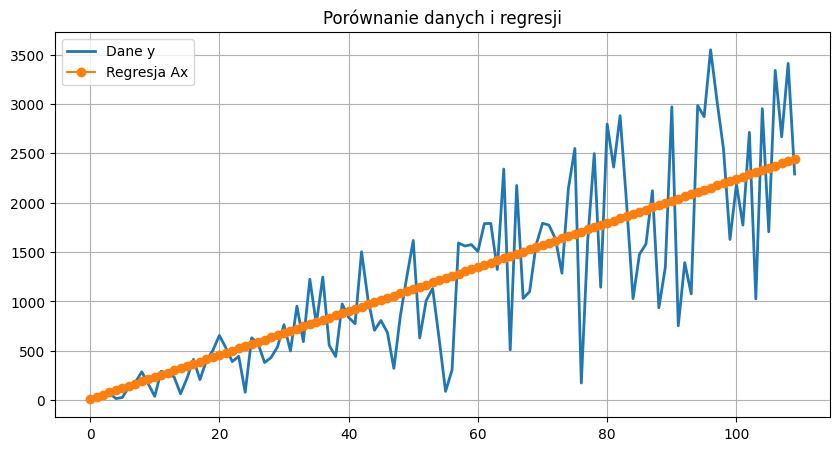

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('war12.csv', sep=';')

df['y'] = df['y'].astype(str).str.replace(',', '.', regex=False).astype(float)

A = df[['x1', 'x2']].to_numpy(dtype=float)
b = df['y'].to_numpy(dtype=float)

print("Pierwsze wiersze danych:")
print(df.head())
print("\nRozmiar A:", A.shape)

U, S, VT = np.linalg.svd(A, full_matrices=False)

print("\nWartości osobliwe:")
print(S)

kappanew = 1e-5
tol = S.max() * kappanew
r = np.sum(S > tol)

print("\nPróg obcięcia:", tol)
print("Przyjęty rząd r:", r)

Ur = U[:, :r]
Sr = np.diag(S[:r])
VTr = VT[:r, :]

A_pinv = VTr.T @ np.linalg.inv(Sr) @ Ur.T

x = A_pinv @ b
a_hat = x[0]
b_hat = x[1]

print("\nWyznaczone współczynniki:")
print("a =", a_hat)
print("b =", b_hat)

y_hat = A @ x

res = b - y_hat
print("\nNorma błędu ||Ax - b||_2 =", np.linalg.norm(res))

x_alt = np.linalg.pinv(A) @ b
print("\nWynik przez np.linalg.pinv(A) @ b:")
print(x_alt)

plt.figure(figsize=(10, 5))
plt.plot(b, linewidth=2, label='Dane y')
plt.plot(y_hat, '-o', label='Regresja Ax')
plt.legend()
plt.grid(True)
plt.title('Porównanie danych i regresji')
plt.show()